In [61]:
# GOAL :: find optimal L2 weight while varying number of relationships

In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt; plt.style.use("dark_background")
import seaborn as sns
import sys
import sys; sys.path.append("/data/jerrylee/pjt/BIGFAM.v.0.1")
import statsmodels.formula.api as smf
import statsmodels.api as sm
from BIGFAM import obj2, tools, frreg
import importlib

In [88]:
source = "UKB" # UKB, GS

# Step 1. Load data

## Step 1.1 FR-reg

In [89]:
frreg_path = f"/data/jerrylee/pjt/BIGFAM.v.0.1/data/{source}/frreg/REL"
pheno_fns = os.listdir(frreg_path)
len(pheno_fns)

106

## Step 1.2 GCTA results

In [286]:
df_gcta = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM/data/gcta/X.all.gcta",
    sep='\t'
)

In [289]:
df_gc = (df_gcta[df_gcta["sex"] == "all"]
         .reset_index(drop=True))
        #  .drop(columns=["sex", "n_meta", "se_X_GCTA"]))

In [291]:
df_gc["lower_GCTA"] = df_gc["X_GCTA"] - 1.96 * df_gc["se_X_GCTA"]
df_gc["upper_GCTA"] = df_gc["X_GCTA"] + 1.96 * df_gc["se_X_GCTA"]
df_gc = df_gc.drop(columns=["sex", "n_meta", "se_X_GCTA"])
df_gc

,pheno,X_GCTA,lower_GCTA,upper_GCTA
0,Nucleated_red_blood_cell_percentage,0.002071,-0.000066,0.004208
1,"Hair_colour__natural,_before_greying_",0.004818,0.002681,0.006954
2,Urate,0.003119,0.000943,0.005295
3,Standing_height,0.020603,0.017991,0.023214
4,IGF-1,0.007575,0.005215,0.009935
...,...,...,...,...
125,Past_tobacco_smoking,0.003393,0.001164,0.005623
126,Arm_fat-free_mass__right_,0.008903,0.006595,0.011210
127,Forced_vital_capacity__FVC_,0.006721,0.004291,0.009151
128,Neuroticism_score,0.002500,-0.000026,0.005025


# Step 2. estimate X

## Step 2.1. Fixed weight

In [176]:
df_bigfam = pd.DataFrame(
    columns=["pheno", "weight", "X_BIGFAM",]
)

for pheno_fn in tqdm(pheno_fns):
    pheno = pheno_fn.split(".")[0]
    df_frreg = pd.read_csv(
        f"{frreg_path}/{pheno_fn}",
        sep='\t'
    )
    
    # regress out mean
    df_block = obj2._regressOutMean(df_frreg, bin=["DOR"])
    
    for alp in range(-3, 3):
        alpha = 2**alp
        result = obj2._optToFindX(df_block, alpha)
        df_bigfam.loc[len(df_bigfam)] = [pheno, alp, result.x[0]]

100%|██████████| 106/106 [00:05<00:00, 18.01it/s]


In [177]:
df_bigfam.groupby("weight").mean()

,X_BIGFAM
weight,
-3,0.017354
-2,0.015093
-1,0.011962
0,0.008455
1,0.005329
2,0.003064


In [178]:
df_mrg = pd.merge(df_bigfam, df_gc, on="pheno")

(-0.01, 0.1)

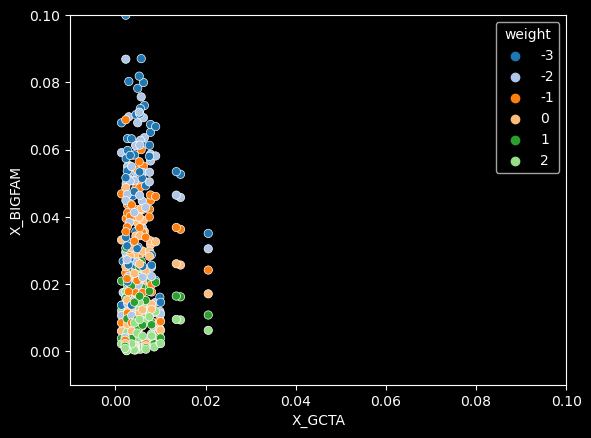

In [179]:
for_plot = df_mrg[(df_mrg["X_BIGFAM"] > 1e-6) & ((df_mrg["X_GCTA"] > 1e-6))]
sns.scatterplot(
    data=for_plot,
    x="X_GCTA",
    y="X_BIGFAM",
    hue="weight",
    palette="tab20")
plt.xlim([-0.01, 0.1])
plt.ylim([-0.01, 0.1])

### Step 2.1.1 plot correlation

In [180]:
df_corr = pd.DataFrame(columns=["weight", "type", "corr"])

for w in sorted(df_mrg["weight"].unique()):
    tmp = df_mrg[df_mrg["weight"] == w]
    
    corr = tmp.corr().iloc[0, 1]
    corr_pos = (tmp[(tmp["X_BIGFAM"] > 1e-6) & (tmp["X_GCTA"] > 1e-6)]
                .corr()
                .iloc[0, 1])
    
    df_corr.loc[len(df_corr)] = [w, "all", corr]
    df_corr.loc[len(df_corr)] = [w, "pos", corr_pos]

<Axes: xlabel='weight', ylabel='corr'>

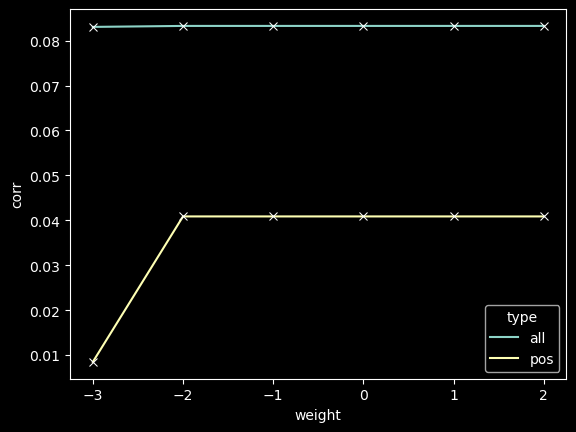

In [181]:
sns.lineplot(
    data=df_corr,
    x="weight",
    y="corr",
    hue="type",
    marker="x"
)

In [182]:
for_plot.groupby("weight").corr()

X_BIGFAM    X_GCTA
weight                             
-3     X_BIGFAM  1.000000  0.008475
       X_GCTA    0.008475  1.000000
-2     X_BIGFAM  1.000000  0.040860
       X_GCTA    0.040860  1.000000
-1     X_BIGFAM  1.000000  0.040860
       X_GCTA    0.040860  1.000000
 0     X_BIGFAM  1.000000  0.040860
       X_GCTA    0.040860  1.000000
 1     X_BIGFAM  1.000000  0.040860
       X_GCTA    0.040860  1.000000
 2     X_BIGFAM  1.000000  0.040860
       X_GCTA    0.040860  1.000000

## Step 2.2 adaptive weight

In [ ]:
df_bigfam = pd.DataFrame(
    columns=["pheno", "weight", "X_BIGFAM", "lower_BIGFAM", "upper_BIGFAM"]
)

for pheno_fn in tqdm(pheno_fns):
    pheno = pheno_fn.split(".")[0]
    df_frreg = pd.read_csv(
        f"{frreg_path}/{pheno_fn}",
        sep='\t'
    )
    
    # regress out mean
    for alp in range(-3, 10):
        result = obj2.estimateX(df_frreg, 
                                alpha_dicts={"type": "eta", "weight":alp})
        
        df_bigfam.loc[len(df_bigfam)] = [pheno, alp, 
                                         np.median(result["X"]),
                                         np.percentile(result["X"], 2.5), 
                                         np.percentile(result["X"], 97.5)]

In [292]:
df_bigfam = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/test/varing_weight.tsv",
    sep='\t'
)

In [294]:
df_mrg = pd.merge(df_bigfam, df_gc, on="pheno")

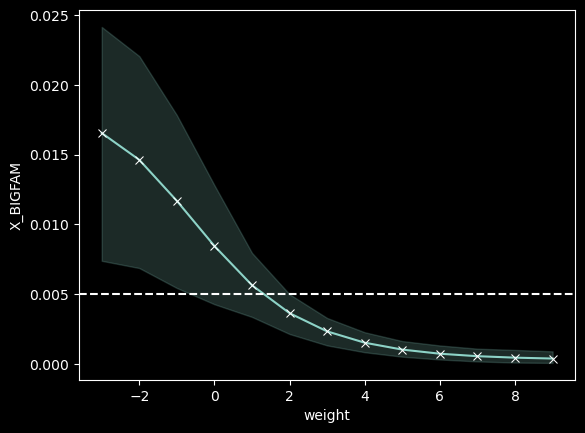

In [262]:
sns.lineplot(
    data=df_mrg,
    x="weight",
    y="X_BIGFAM",
    marker="x")
plt.axhline(df_mrg["X_GCTA"].mean(), ls="--")

### Step 2.2.1 plot correlation

In [264]:
# excludes = ["Platelet_count", "Lipoprotein_A"]
x_thred = 1e-4

In [265]:
df_corr = pd.DataFrame(columns=["weight", "type", "corr"])

for w in sorted(df_mrg["weight"].unique()):
    tmp = df_mrg[df_mrg["weight"] == w]
    # tmp = tmp[~tmp["pheno"].isin(excludes)]
    
    corr = tmp.corr().iloc[0, 1]
    corr_pos = (tmp[(tmp["X_BIGFAM"] > x_thred) & (tmp["X_GCTA"] > x_thred)]
                .corr()
                .iloc[0, 1])
    
    df_corr.loc[len(df_corr)] = [w, "all", corr]
    df_corr.loc[len(df_corr)] = [w, "pos", corr_pos]

<Axes: xlabel='weight', ylabel='corr'>

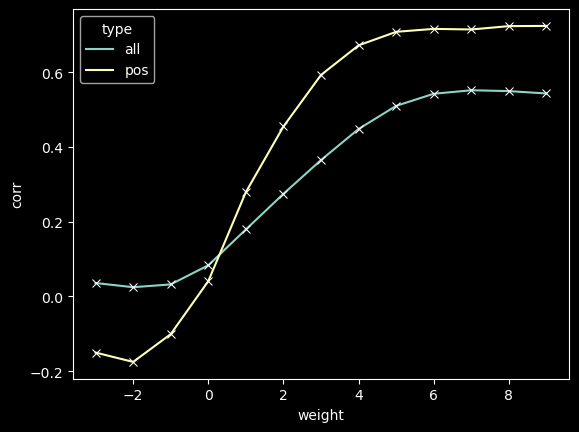

In [266]:
sns.lineplot(
    data=df_corr,
    x="weight",
    y="corr",
    hue="type",
    marker="x"
)

In [269]:
for_plot = df_mrg[
    (df_mrg["X_BIGFAM"] > x_thred)\
    & (df_mrg["X_GCTA"] > x_thred)\
    & (df_mrg["weight"] == 1)]

for_plot.mean()

/tmp/ipykernel_167913/841573329.py:6: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  for_plot.mean()


weight      1.000000
X_BIGFAM    0.012139
X_GCTA      0.005240
dtype: float64

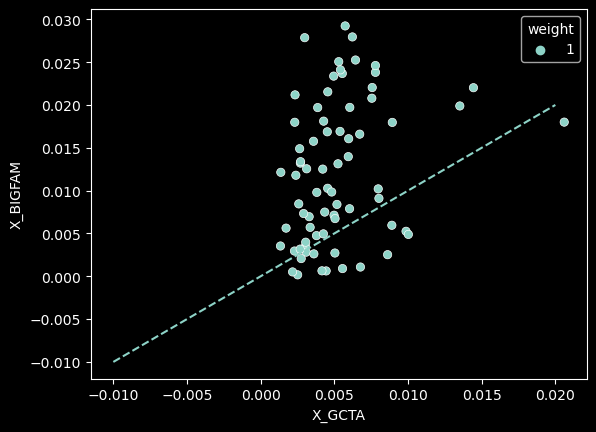

In [270]:
sns.scatterplot(
    data=for_plot,
    x="X_GCTA",
    y="X_BIGFAM",
    hue="weight",)
plt.plot([-0.01, 0.02], [-0.01, 0.02], ls="--")
# plt.xlim([-0.01, 0.1])
# plt.ylim([-0.01, 0.1])

In [254]:
for_plot["diff"] = np.abs(for_plot["X_BIGFAM"] - for_plot["X_GCTA"])

In [255]:
for_plot[for_plot["diff"] > 0.008]

,pheno,weight,X_BIGFAM,X_GCTA,diff
398,Whole_body_fat-free_mass,5,0.001583,0.009866,0.008283
684,Whole_body_water_mass,5,0.001455,0.010024,0.008569
905,Mean_platelet__thrombocyte__volume,5,0.004956,0.013515,0.008559


[<Axes: xlabel='diff', ylabel='Count'>]

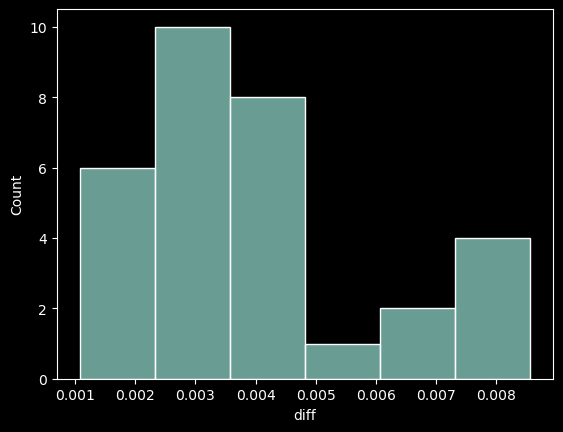

In [256]:
[sns.histplot(
    data=for_plot.sort_values(by="diff"),
    x="diff")]

In [ ]:
["Platelet_count", "Lipoprotein_A"]